# Heart Disease Prediction
# Phase 3 — Baseline Model Training
### UCI Cleveland Heart Disease Dataset
---
**Input:** Preprocessed files saved to Drive

**Goal:** Train 8 models on all features without any removal (Baseline)

**Models:**
1. Logistic Regression
2. Decision Tree
3. Random Forest
4. Support Vector Machine (SVM)
5. K-Nearest Neighbors (KNN)
6. XGBoost
7. Naive Bayes
8. Neural Network (MLP)

**Outputs:**
- Baseline comparison table
- Confusion Matrix for each model
- ROC Curves for all models
- Comparison Bar Chart
- Save all results for the next phase

---
##  Cell 1 — Install & Import Libraries

In [1]:
# ============================================================
# CELL 1 — Install & Import All Required Libraries
# ============================================================

# Install xgboost — not always pre-installed in Colab
!pip install xgboost --quiet

# --- Core libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import os
import joblib
import warnings
warnings.filterwarnings('ignore')

# --- The 8 Models ---
from sklearn.linear_model    import LogisticRegression          # Model 1
from sklearn.tree            import DecisionTreeClassifier       # Model 2
from sklearn.ensemble        import RandomForestClassifier       # Model 3
from sklearn.svm             import SVC                          # Model 4
from sklearn.neighbors       import KNeighborsClassifier         # Model 5
from xgboost                 import XGBClassifier                # Model 6
from sklearn.naive_bayes     import GaussianNB                   # Model 7
from sklearn.neural_network  import MLPClassifier                # Model 8

# --- Evaluation metrics ---
from sklearn.metrics import (
    accuracy_score,       # ratio of correct predictions
    precision_score,      # of those predicted sick, how many are correct?
    recall_score,         # of all actual sick patients, how many did we catch? (most important medically)
    f1_score,             # balance between precision and recall
    roc_auc_score,        # how well the model separates the two classes
    confusion_matrix,     # detailed breakdown of errors
    roc_curve,            # ROC curve for plotting
    classification_report # full classification report
)
from sklearn.model_selection import cross_val_score  # 10-Fold Cross Validation

# --- Plot settings ---
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print('=' * 55)
print('   All libraries imported successfully!')
print('=' * 55)

   All libraries imported successfully!


---
##  Cell 2 — Load Preprocessed Data from Drive
> Load the data prepared in the Preprocessing phase — no need to redo the work from scratch

In [2]:
# ============================================================
# CELL 2 — Load All Preprocessed Data from Google Drive
# ============================================================

# Mount Google Drive to access saved files
# from google.colab import drive
# drive.mount('/content/drive')

# Path to the saved preprocessing outputs
LOAD_DIR = 'saved_data'

# --- Load all files ---
# X_train_scaled: training features after SMOTE + StandardScaler
# Used for: LR, SVM, KNN, Neural Network (scale-sensitive models)
X_train = joblib.load(f'{LOAD_DIR}/X_train_scaled.pkl')

# X_test_scaled: test features after StandardScaler
X_test  = joblib.load(f'{LOAD_DIR}/X_test_scaled.pkl')

# y_train: training labels (after SMOTE balancing)
y_train = joblib.load(f'{LOAD_DIR}/y_train.pkl')

# y_test: test labels (original — never modified)
y_test  = joblib.load(f'{LOAD_DIR}/y_test.pkl')

# feature_names: list of column names after One-Hot Encoding
feature_names = joblib.load(f'{LOAD_DIR}/feature_names.pkl')

# Convert to proper pandas objects if needed
X_train = pd.DataFrame(X_train, columns=feature_names) if not isinstance(X_train, pd.DataFrame) else X_train
X_test  = pd.DataFrame(X_test,  columns=feature_names) if not isinstance(X_test,  pd.DataFrame) else X_test
y_train = pd.Series(y_train) if not isinstance(y_train, pd.Series) else y_train
y_test  = pd.Series(y_test)  if not isinstance(y_test,  pd.Series) else y_test

# Reset indices to avoid alignment issues
X_train = X_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

print('Data loaded successfully!')
print(f'  X_train : {X_train.shape}  (training features)')
print(f'  X_test  : {X_test.shape}   (test features)')
print(f'  y_train : {y_train.shape}  | classes: {y_train.value_counts().to_dict()}')
print(f'  y_test  : {y_test.shape}   | classes: {y_test.value_counts().to_dict()}')
print(f'  Features: {feature_names}')

Data loaded successfully!
  X_train : (262, 22)  (training features)
  X_test  : (61, 22)   (test features)
  y_train : (262,)  | classes: {1: 131, 0: 131}
  y_test  : (61,)   | classes: {0: 33, 1: 28}
  Features: ['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak', 'cp_2.0', 'cp_3.0', 'cp_4.0', 'restecg_1.0', 'restecg_2.0', 'slope_2.0', 'slope_3.0', 'thal_4', 'thal_5', 'thal_6', 'thal_7', 'ca_1', 'ca_2', 'ca_3']


---
##  Cell 3 — Define All 8 Models
> Define each model with its default settings — this is called Baseline because no tuning or optimization is applied

In [3]:
# ============================================================
# CELL 3 — Define All 8 Classifiers
# ============================================================

# random_state=42 in all models → reproducible results
# probability=True in SVM → needed to calculate ROC-AUC

models = {

    # --- Model 1: Logistic Regression ---
    # Linear model — finds the best decision boundary (line/plane)
    # max_iter=1000: increase iterations to ensure convergence
    'Logistic Regression': LogisticRegression(
        random_state=42,
        max_iter=1000
    ),

    # --- Model 2: Decision Tree ---
    # Builds a tree of yes/no questions to classify patients
    # max_depth=5: limits tree depth to avoid memorizing training data (overfitting)
    'Decision Tree': DecisionTreeClassifier(
        random_state=42,
        max_depth=5
    ),

    # --- Model 3: Random Forest ---
    # Many decision trees vote together — more accurate than one tree
    # n_estimators=100: build 100 trees
    'Random Forest': RandomForestClassifier(
        random_state=42,
        n_estimators=100
    ),

    # --- Model 4: Support Vector Machine ---
    # Finds the widest possible margin between the two classes
    # kernel='rbf': handles non-linear boundaries
    # probability=True: required to compute ROC-AUC score
    'SVM': SVC(
        random_state=42,
        kernel='rbf',
        probability=True
    ),

    # --- Model 5: K-Nearest Neighbors ---
    # Classifies a patient based on the 5 most similar patients
    # n_neighbors=5: look at 5 nearest neighbors
    'KNN': KNeighborsClassifier(
        n_neighbors=5
    ),

    # --- Model 6: XGBoost ---
    # Powerful boosting model — builds trees sequentially, each correcting the last
    # eval_metric='logloss': suppress warnings
    # use_label_encoder=False: avoid deprecation warning
    'XGBoost': XGBClassifier(
        random_state=42,
        n_estimators=100,
        eval_metric='logloss',
        use_label_encoder=False
    ),

    # --- Model 7: Naive Bayes ---
    # Probabilistic model based on Bayes theorem
    # Assumes features are independent from each other (naive assumption)
    # Fast and works well even with small data
    'Naive Bayes': GaussianNB(),

    # --- Model 8: Neural Network (MLP) ---
    # Multi-Layer Perceptron — mimics how neurons work in the brain
    # hidden_layer_sizes=(64,32): 2 hidden layers with 64 and 32 neurons
    # activation='relu': non-linear activation function
    # max_iter=500: train for up to 500 epochs
    'Neural Network': MLPClassifier(
        random_state=42,
        hidden_layer_sizes=(64, 32),
        activation='relu',
        max_iter=500
    )
}

print(f'   {len(models)} models defined and ready for training!')
print()
for i, name in enumerate(models.keys(), 1):
    print(f'  {i}. {name}')

   8 models defined and ready for training!

  1. Logistic Regression
  2. Decision Tree
  3. Random Forest
  4. SVM
  5. KNN
  6. XGBoost
  7. Naive Bayes
  8. Neural Network


---
##  Cell 4 — Train All Models + Evaluate
> Train each model and compute 6 metrics at once — results are stored in a table

In [4]:
# ============================================================
# CELL 4 — Train All 8 Models + Calculate All Metrics
# ============================================================

# Dictionary to store results for each model
baseline_results = {}

# Dictionary to store trained model objects (needed for plots later)
trained_models = {}

# Dictionary to store predictions (needed for confusion matrices)
predictions = {}

print('Training all 8 models...')
print('=' * 65)

for name, model in models.items():
    print(f'  Training: {name}...')

    # --- Step 1: Train the model ---
    # fit() = train on X_train using y_train as the ground truth
    model.fit(X_train, y_train)

    # --- Step 2: Make predictions on the TEST set ---
    # predict() returns class labels (0 or 1)
    y_pred = model.predict(X_test)

    # predict_proba() returns probability scores [prob_class0, prob_class1]
    # We take [:, 1] = probability of being sick (class 1)
    # Used for ROC-AUC calculation
    y_prob = model.predict_proba(X_test)[:, 1]

    # --- Step 3: Calculate all 6 metrics ---

    # Accuracy: what % of predictions were correct overall
    acc = accuracy_score(y_test, y_pred)

    # Precision: of patients we said are SICK, how many actually are?
    # High precision = few false alarms
    prec = precision_score(y_test, y_pred, zero_division=0)

    # Recall (Sensitivity): of ALL actual sick patients, how many did we catch?
    # THE MOST IMPORTANT metric in medical diagnosis
    # Missing a sick patient is far worse than a false alarm
    rec = recall_score(y_test, y_pred, zero_division=0)

    # F1-Score: harmonic mean of Precision and Recall
    # Balances both — especially useful with imbalanced data
    f1 = f1_score(y_test, y_pred, zero_division=0)

    # ROC-AUC: measures how well the model separates the two classes
    # 1.0 = perfect, 0.5 = random guessing
    auc = roc_auc_score(y_test, y_prob)

    # CV Score: 10-Fold Cross Validation accuracy
    # Splits training data into 10 parts, trains 10 times
    # More reliable than a single train/test split
    cv = cross_val_score(model, X_train, y_train, cv=10, scoring='accuracy').mean()

    # --- Step 4: Store results ---
    baseline_results[name] = {
        'Accuracy':  round(acc  * 100, 2),
        'Precision': round(prec * 100, 2),
        'Recall':    round(rec  * 100, 2),
        'F1-Score':  round(f1   * 100, 2),
        'ROC-AUC':   round(auc  * 100, 2),
        'CV Score':  round(cv   * 100, 2)
    }

    # Store trained model and predictions for later use
    trained_models[name] = model
    predictions[name]    = {'y_pred': y_pred, 'y_prob': y_prob}

    print(f'    Accuracy={acc*100:.1f}%  Recall={rec*100:.1f}%  AUC={auc*100:.1f}%')

print('=' * 65)
print('   All 8 models trained successfully!')

Training all 8 models...
  Training: Logistic Regression...
    Accuracy=85.2%  Recall=85.7%  AUC=94.0%
  Training: Decision Tree...
    Accuracy=68.9%  Recall=64.3%  AUC=77.3%
  Training: Random Forest...
    Accuracy=90.2%  Recall=96.4%  AUC=95.1%
  Training: SVM...
    Accuracy=90.2%  Recall=100.0%  AUC=93.0%
  Training: KNN...
    Accuracy=85.2%  Recall=96.4%  AUC=93.3%
  Training: XGBoost...
    Accuracy=86.9%  Recall=92.9%  AUC=91.6%
  Training: Naive Bayes...
    Accuracy=83.6%  Recall=82.1%  AUC=81.7%
  Training: Neural Network...
    Accuracy=80.3%  Recall=78.6%  AUC=87.7%
   All 8 models trained successfully!


---
##  Cell 5 — Baseline Results Table
> Display a comparison table for all models — this is the Baseline we will compare against after Feature Selection

In [5]:
# ============================================================
# CELL 5 — Display Baseline Results Table
# ============================================================

# Convert results dictionary to a DataFrame for easy display
baseline_df = pd.DataFrame(baseline_results).T  # .T = transpose: models as rows
baseline_df.index.name = 'Model'

# Sort by F1-Score descending (best model on top)
baseline_df = baseline_df.sort_values('F1-Score', ascending=False)

print('=' * 70)
print('          BASELINE RESULTS — All 8 Models (No Feature Selection)')
print('          All values in % | Sorted by F1-Score')
print('=' * 70)
display(baseline_df.style
    .format('{:.2f}%')                              # Add % sign to all values
    .background_gradient(cmap='YlGn', axis=0)       # Green = higher = better
    .highlight_max(color='#2ecc71', axis=0)         # Highlight best value per column
    .highlight_min(color='#ffcccc', axis=0)         # Highlight worst value per column
    .set_caption('Baseline Performance — Higher is Better')
)

# Print the best model per metric
print()
print('Best model per metric:')
print('-' * 45)
for metric in baseline_df.columns:
    best_model = baseline_df[metric].idxmax()
    best_val   = baseline_df[metric].max()
    # Recall gets a star because it's most important medically
    star = '  (Most important medically!)' if metric == 'Recall' else ''
    print(f'  {metric:<12}: {best_model:<22} ({best_val:.2f}%){star}')

          BASELINE RESULTS — All 8 Models (No Feature Selection)
          All values in % | Sorted by F1-Score


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,CV Score
Model,,,,,,
SVM,90.16%,82.35%,100.00%,90.32%,93.02%,81.64%
Random Forest,90.16%,84.38%,96.43%,90.00%,95.08%,77.45%
XGBoost,86.89%,81.25%,92.86%,86.67%,91.56%,81.27%
KNN,85.25%,77.14%,96.43%,85.71%,93.29%,78.16%
Logistic Regression,85.25%,82.76%,85.71%,84.21%,94.05%,80.83%
Naive Bayes,83.61%,82.14%,82.14%,82.14%,81.71%,75.87%
Neural Network,80.33%,78.57%,78.57%,78.57%,87.66%,77.79%
Decision Tree,68.85%,66.67%,64.29%,65.45%,77.33%,70.57%



Best model per metric:
---------------------------------------------
  Accuracy    : SVM                    (90.16%)
  Precision   : Random Forest          (84.38%)
  Recall      : SVM                    (100.00%)  (Most important medically!)
  F1-Score    : SVM                    (90.32%)
  ROC-AUC     : Random Forest          (95.08%)
  CV Score    : SVM                    (81.64%)


---
##  Cell 6 — Confusion Matrix for Each Model
> The Confusion Matrix shows in detail where the model was correct and where it made mistakes — medically important to understand the type of errors

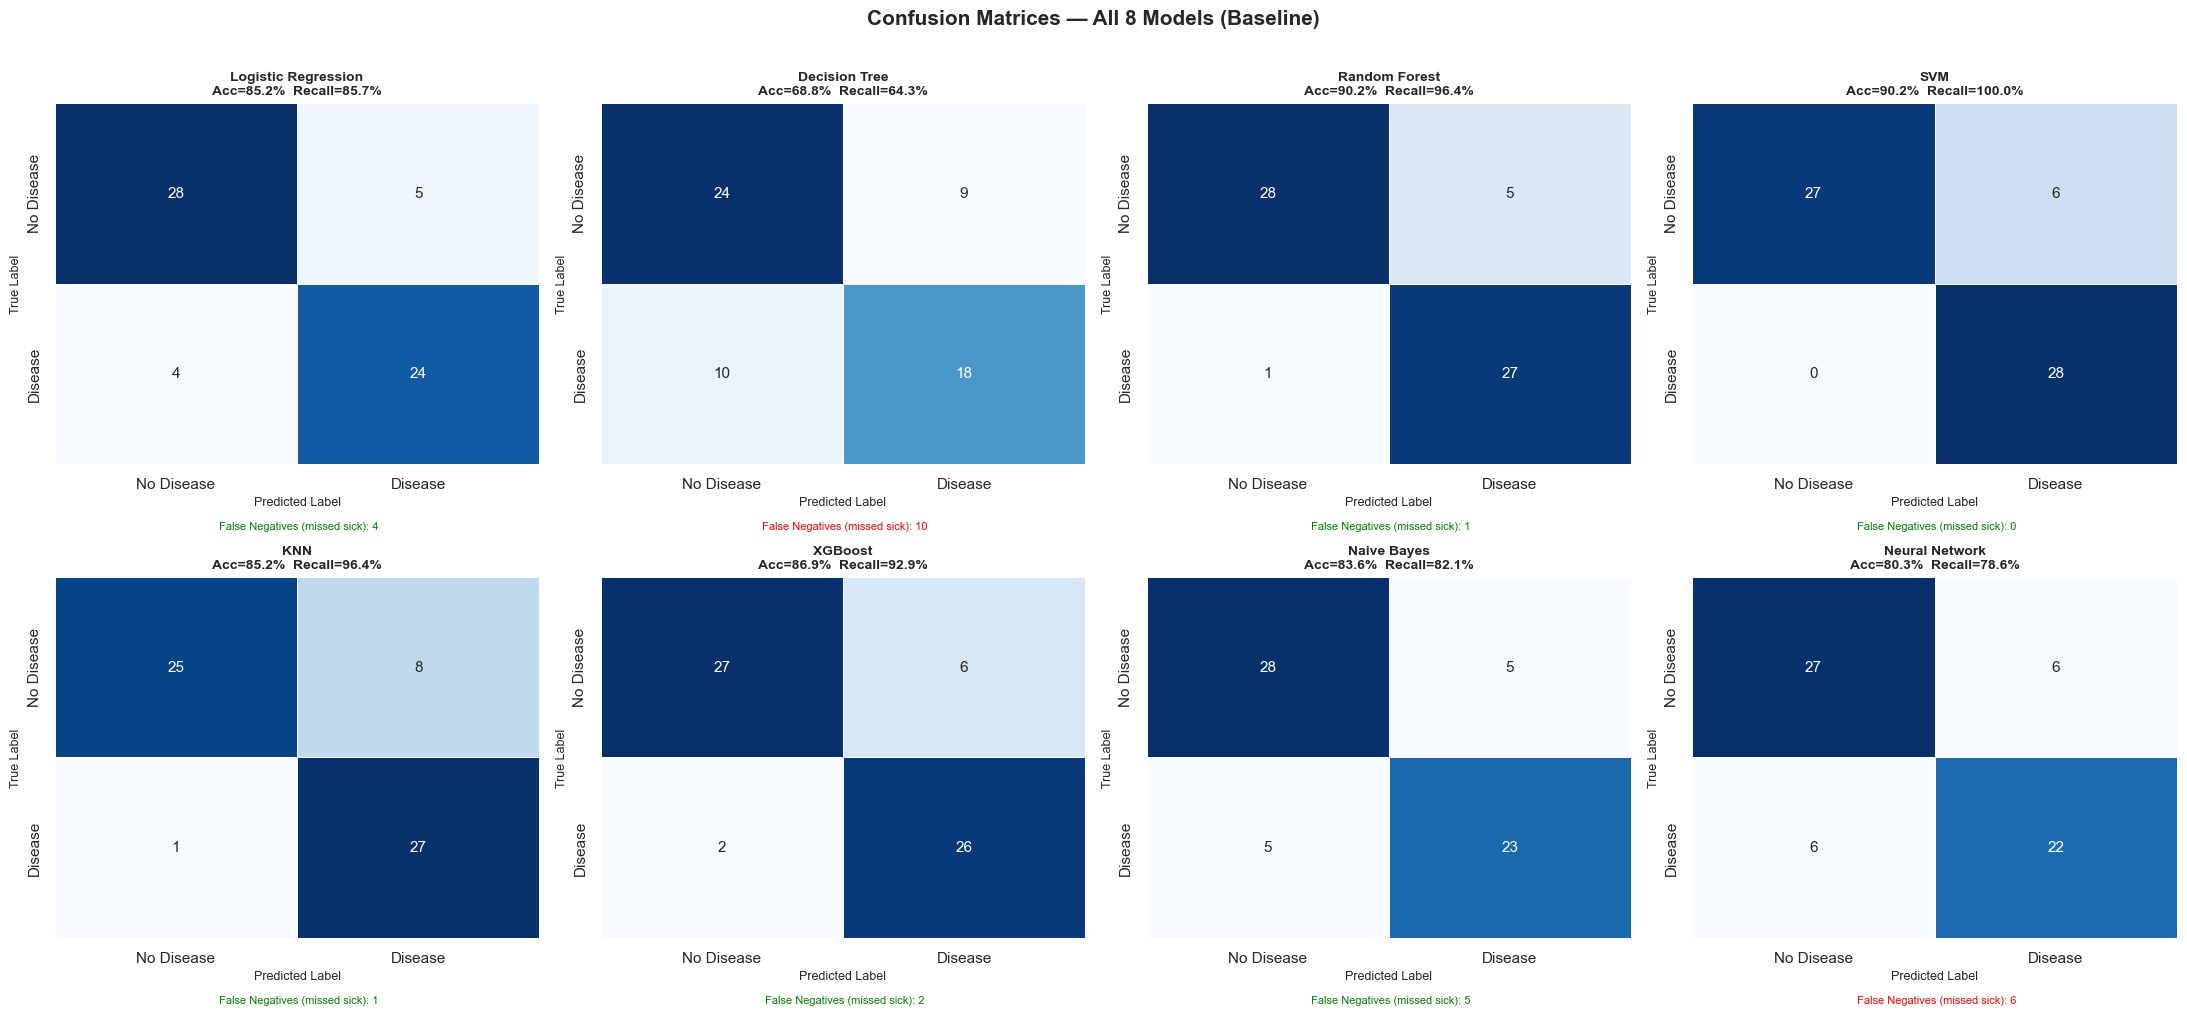

   Confusion matrices saved!

False Negatives Summary (missed sick patients — lower is better):
--------------------------------------------------
   Logistic Regression      : 4 missed sick patients
   Decision Tree            : 10 missed sick patients
   Random Forest            : 1 missed sick patients
   SVM                      : 0 missed sick patients
   KNN                      : 1 missed sick patients
   XGBoost                  : 2 missed sick patients
   Naive Bayes              : 5 missed sick patients
   Neural Network           : 6 missed sick patients

   Best (fewest missed): SVM (0 missed)


In [6]:
# ============================================================
# CELL 6 — Confusion Matrices for All 8 Models
# ============================================================

# --- What is a Confusion Matrix? ---
# A 2x2 table showing:
#
#                  Predicted NO    Predicted YES
#  Actual NO    [ True Negative  | False Positive ]
#  Actual YES   [ False Negative | True Positive  ]
#
# True Positive  (TP): Sick patient, model said SICK    
# True Negative  (TN): Healthy patient, model said HEALTHY 
# False Positive (FP): Healthy patient, model said SICK   (false alarm)
# False Negative (FN): Sick patient, model said HEALTHY  (DANGEROUS in medicine!)

model_names = list(trained_models.keys())
n_models    = len(model_names)

# Create a grid: 2 rows × 4 columns = 8 subplots
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.suptitle('Confusion Matrices — All 8 Models (Baseline)',
             fontsize=15, fontweight='bold', y=1.01)

axes_flat = axes.flatten()  # Flatten 2D array to 1D for easy iteration

for i, name in enumerate(model_names):
    ax = axes_flat[i]

    # Calculate the confusion matrix
    y_pred = predictions[name]['y_pred']
    cm     = confusion_matrix(y_test, y_pred)

    # Extract the 4 values from the confusion matrix
    tn, fp, fn, tp = cm.ravel()

    # Plot the heatmap
    sns.heatmap(
        cm,
        annot=True,              # Show numbers inside each cell
        fmt='d',                 # Integer format
        cmap='Blues',            # Blue color scheme
        ax=ax,
        xticklabels=['No Disease', 'Disease'],
        yticklabels=['No Disease', 'Disease'],
        linewidths=0.5,
        cbar=False               # No color bar (saves space)
    )

    # Get metrics for this model
    acc = baseline_results[name]['Accuracy']
    rec = baseline_results[name]['Recall']

    ax.set_title(f'{name}\nAcc={acc:.1f}%  Recall={rec:.1f}%',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=9)
    ax.set_ylabel('True Label', fontsize=9)

    # Add a small annotation showing FN count (most critical medical error)
    ax.text(0.5, -0.18, f' False Negatives (missed sick): {fn}',
            transform=ax.transAxes, ha='center', fontsize=8,
            color='red' if fn > 5 else 'green')

plt.tight_layout()
plt.savefig('baseline_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('   Confusion matrices saved!')

# Print False Negative summary — most critical for medical use
print()
print('False Negatives Summary (missed sick patients — lower is better):')
print('-' * 50)
fn_summary = {}
for name in model_names:
    cm = confusion_matrix(y_test, predictions[name]['y_pred'])
    fn = cm[1][0]  # Row 1 (actual sick), Column 0 (predicted healthy)
    fn_summary[name] = fn
    flag = '' if fn > 5 else ''
    print(f'  {flag} {name:<25}: {fn} missed sick patients')
best_fn = min(fn_summary, key=fn_summary.get)
print(f'\n   Best (fewest missed): {best_fn} ({fn_summary[best_fn]} missed)')

---
##  Cell 7 — ROC Curves for All Models
> The ROC Curve shows how well the model distinguishes between sick and healthy patients — the higher and closer to the top-left corner, the better

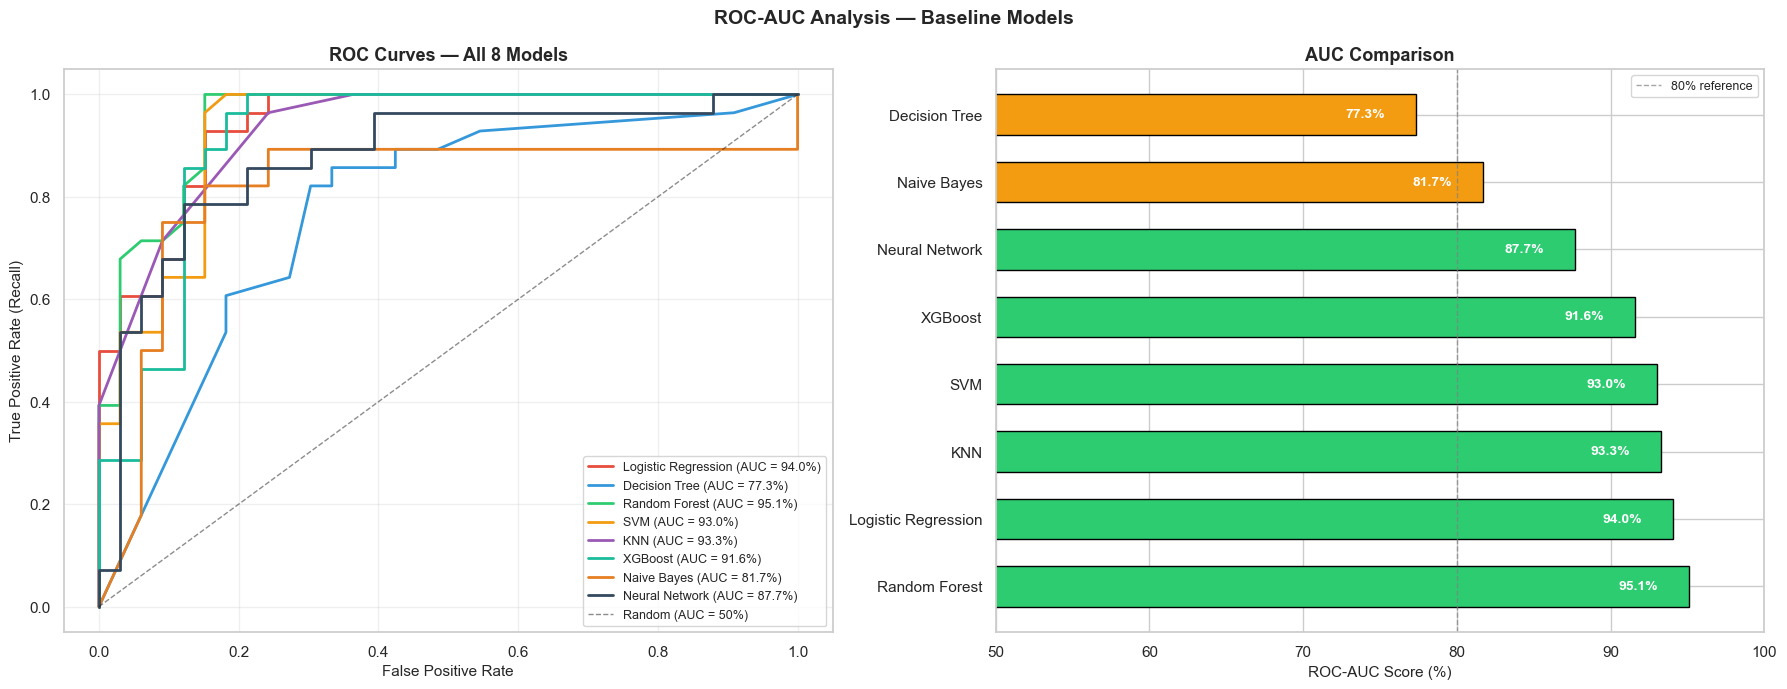

   ROC curves saved!


In [7]:
# ============================================================
# CELL 7 — ROC Curves for All 8 Models (One Plot)
# ============================================================

# --- What is ROC Curve? ---
# ROC = Receiver Operating Characteristic
# X-axis: False Positive Rate (how often we falsely alarm healthy patients)
# Y-axis: True Positive Rate / Recall (how often we catch actual sick patients)
#
# Perfect model: curve goes to top-left corner (AUC = 1.0)
# Random model:  diagonal line from bottom-left to top-right (AUC = 0.5)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Plot 1: All ROC curves on one graph ---
# Use a distinct color for each model
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12',
          '#9b59b6', '#1abc9c', '#e67e22', '#34495e']

for i, name in enumerate(model_names):
    y_prob = predictions[name]['y_prob']
    auc    = baseline_results[name]['ROC-AUC']

    # roc_curve() returns: false positive rates, true positive rates, thresholds
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    axes[0].plot(fpr, tpr,
                 color=colors[i],
                 linewidth=2,
                 label=f'{name} (AUC = {auc:.1f}%)')

# Diagonal line = random classifier (AUC = 0.5) — reference line
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random (AUC = 50%)')
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate (Recall)', fontsize=11)
axes[0].set_title('ROC Curves — All 8 Models', fontsize=13, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=9)
axes[0].grid(True, alpha=0.3)

# --- Plot 2: AUC Bar Chart for easy comparison ---
auc_values = [baseline_results[name]['ROC-AUC'] for name in model_names]
auc_sorted = sorted(zip(auc_values, model_names), reverse=True)
auc_vals_sorted  = [x[0] for x in auc_sorted]
model_names_sorted = [x[1] for x in auc_sorted]

# Color bars: green for high AUC, red for low
bar_colors = ['#2ecc71' if v >= 85 else '#f39c12' if v >= 75 else '#e74c3c'
              for v in auc_vals_sorted]

bars = axes[1].barh(model_names_sorted, auc_vals_sorted,
                    color=bar_colors, edgecolor='black', height=0.6)

# Add value labels on bars
for bar, val in zip(bars, auc_vals_sorted):
    axes[1].text(bar.get_width() - 2, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', ha='right',
                fontweight='bold', fontsize=10, color='white')

# Add a reference line at 80%
axes[1].axvline(80, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='80% reference')
axes[1].set_xlabel('ROC-AUC Score (%)', fontsize=11)
axes[1].set_title('AUC Comparison', fontsize=13, fontweight='bold')
axes[1].set_xlim(50, 100)
axes[1].legend(fontsize=9)

plt.suptitle('ROC-AUC Analysis — Baseline Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('baseline_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('   ROC curves saved!')

---
##  Cell 8 — Grouped Bar Chart: All Metrics Comparison
> Compare all models across all 6 metrics — clearly shows which model performs best in each aspect

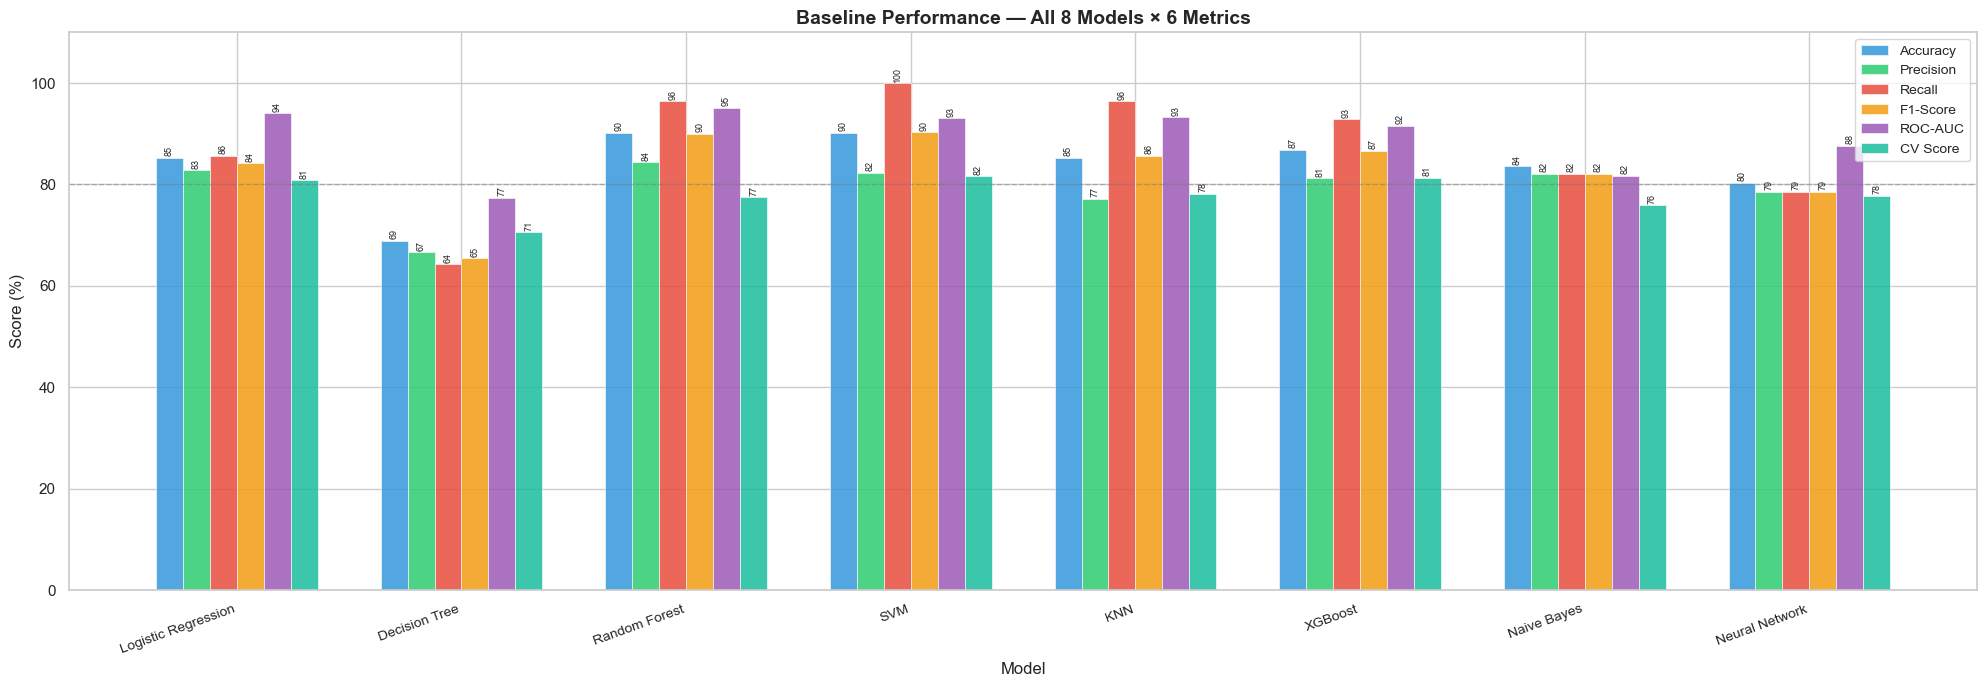

   Grouped bar chart saved!


In [8]:
# ============================================================
# CELL 8 — Grouped Bar Chart: All Metrics for All Models
# ============================================================

metrics    = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'CV Score']
x          = np.arange(len(model_names))  # Positions on x-axis
n_metrics  = len(metrics)
bar_width  = 0.12  # Width of each bar

# Colors for each metric
metric_colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6', '#1abc9c']

fig, ax = plt.subplots(figsize=(20, 7))

for i, (metric, color) in enumerate(zip(metrics, metric_colors)):
    # Get values for this metric across all models
    values = [baseline_results[name][metric] for name in model_names]

    # Calculate bar position — offset each metric group
    positions = x + (i - n_metrics/2) * bar_width + bar_width/2

    bars = ax.bar(positions, values, bar_width,
                  label=metric, color=color,
                  alpha=0.85, edgecolor='white', linewidth=0.5)

    # Add value labels on top of each bar
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.3,
                f'{val:.0f}', ha='center', va='bottom',
                fontsize=6.5, rotation=90)

# Formatting
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Baseline Performance — All 8 Models × 6 Metrics',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=20, ha='right', fontsize=10)
ax.set_ylim(0, 110)  # Leave space for labels above bars
ax.legend(loc='upper right', fontsize=10)
ax.axhline(80, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='80% line')

plt.tight_layout()
plt.savefig('baseline_grouped_barchart.png', dpi=150, bbox_inches='tight')
plt.show()
print('   Grouped bar chart saved!')

---
##  Cell 9 — Performance Heatmap
> Same results table visualized as a Heatmap — colors quickly highlight where performance is high and where it is low

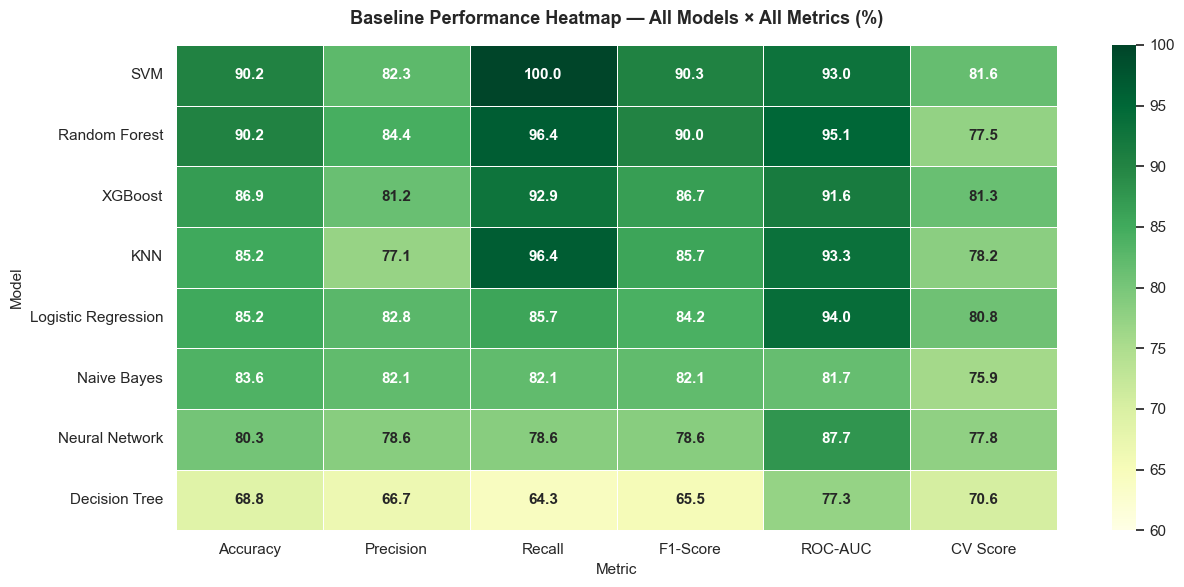

   Performance heatmap saved!


In [9]:
# ============================================================
# CELL 9 — Performance Heatmap
# ============================================================

# Heatmap gives a quick visual overview:
# Dark green = high score = good
# Light yellow = low score = needs improvement

plt.figure(figsize=(13, 6))

# baseline_df is already sorted by F1-Score from Cell 5
sns.heatmap(
    baseline_df,
    annot=True,           # Show numbers inside cells
    fmt='.1f',            # One decimal place
    cmap='YlGn',          # Yellow = low, Green = high
    linewidths=0.5,
    linecolor='white',
    annot_kws={'size': 11, 'weight': 'bold'},
    vmin=60, vmax=100     # Color scale from 60% to 100%
)

plt.title('Baseline Performance Heatmap — All Models × All Metrics (%)',
          fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Metric', fontsize=11)
plt.ylabel('Model', fontsize=11)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('baseline_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('   Performance heatmap saved!')

---
##  Cell 10 — Detailed Classification Report


In [10]:
# ============================================================
# CELL 10 — Detailed Classification Report for Each Model
# ============================================================

# classification_report shows precision, recall, f1 per class:
# Class 0 (No Disease): how well do we identify healthy patients?
# Class 1 (Disease):    how well do we identify sick patients?

print('DETAILED CLASSIFICATION REPORTS')
print('=' * 65)

for name in model_names:
    y_pred = predictions[name]['y_pred']

    print(f'\n   {name}')
    print('-' * 50)
    print(classification_report(
        y_test, y_pred,
        target_names=['No Disease (0)', 'Disease (1)'],
        digits=3   # 3 decimal places for precision
    ))

    # Highlight the key metric — Recall for disease class
    rec_sick = recall_score(y_test, y_pred)
    flag = ' Good' if rec_sick >= 0.80 else ' Needs improvement'
    print(f'  Recall for Sick Patients: {rec_sick*100:.1f}%  {flag}')
    print()

DETAILED CLASSIFICATION REPORTS

   Logistic Regression
--------------------------------------------------
                precision    recall  f1-score   support

No Disease (0)      0.875     0.848     0.862        33
   Disease (1)      0.828     0.857     0.842        28

      accuracy                          0.852        61
     macro avg      0.851     0.853     0.852        61
  weighted avg      0.853     0.852     0.853        61

  Recall for Sick Patients: 85.7%   Good


   Decision Tree
--------------------------------------------------
                precision    recall  f1-score   support

No Disease (0)      0.706     0.727     0.716        33
   Disease (1)      0.667     0.643     0.655        28

      accuracy                          0.689        61
     macro avg      0.686     0.685     0.685        61
  weighted avg      0.688     0.689     0.688        61

  Recall for Sick Patients: 64.3%   Needs improvement


   Random Forest
-------------------------------

---
##  Cell 11 — Save Everything for Feature Selection


In [11]:
# ============================================================
# CELL 11 — Save All Results & Models for Next Phase
# ============================================================

SAVE_DIR = 'saved_data'
os.makedirs(SAVE_DIR, exist_ok=True)

# --- Save baseline results table (CSV + pkl) ---
# CSV: easy to open in Excel or share
baseline_df.to_csv(f'{SAVE_DIR}/baseline_results.csv')
print('   baseline_results.csv     → results table (open in Excel)')

# PKL: for loading back in Python
joblib.dump(baseline_results, f'{SAVE_DIR}/baseline_results.pkl')
print('   baseline_results.pkl     → results dict (for Python use)')

# --- Save all trained model objects ---
# These will be retrained on selected features in the next phase
# but we save them here for reference
joblib.dump(trained_models, f'{SAVE_DIR}/baseline_models.pkl')
print('   baseline_models.pkl      → all 8 trained model objects')

# --- Save predictions (y_pred and y_prob for each model) ---
joblib.dump(predictions, f'{SAVE_DIR}/baseline_predictions.pkl')
print('   baseline_predictions.pkl → predictions + probabilities')

# --- Save model names list (needed in Feature Selection notebook) ---
joblib.dump(model_names, f'{SAVE_DIR}/model_names.pkl')
print('   model_names.pkl          → list of model names')

# --- Save model definitions (untrained) for re-training after FS ---
# Feature Selection notebook will retrain these on the selected features
joblib.dump(models, f'{SAVE_DIR}/model_definitions.pkl')
print('   model_definitions.pkl    → untrained model definitions')

print()
print('   All outputs saved to Google Drive!')
print(f'   Location: {SAVE_DIR}')

   baseline_results.csv     → results table (open in Excel)
   baseline_results.pkl     → results dict (for Python use)
   baseline_models.pkl      → all 8 trained model objects
   baseline_predictions.pkl → predictions + probabilities
   model_names.pkl          → list of model names
   model_definitions.pkl    → untrained model definitions

   All outputs saved to Google Drive!
   Location: saved_data


---
##  Cell 12 — Final Baseline Summary Report

In [12]:
# ============================================================
# CELL 12 — Final Baseline Summary Report
# ============================================================

best_acc = baseline_df['Accuracy'].idxmax()
best_rec = baseline_df['Recall'].idxmax()
best_f1  = baseline_df['F1-Score'].idxmax()
best_auc = baseline_df['ROC-AUC'].idxmax()

print('=' * 65)
print('              BASELINE SUMMARY REPORT')
print('      Heart Disease Prediction — UCI Cleveland Dataset')
print('=' * 65)
print(f'  Dataset          : {X_train.shape[0]} train | {X_test.shape[0]} test samples')
print(f'  Features used    : {X_train.shape[1]} features (all — no selection yet)')
print(f'  Models trained   : {len(model_names)}')
print()
print('  BEST MODELS:')
print(f'  Best Accuracy  : {best_acc:<25} ({baseline_df.loc[best_acc, "Accuracy"]:.2f}%)')
print(f'  Best Recall  : {best_rec:<25} ({baseline_df.loc[best_rec, "Recall"]:.2f}%) ← Most important medically')
print(f'  Best F1-Score  : {best_f1:<25} ({baseline_df.loc[best_f1, "F1-Score"]:.2f}%)')
print(f'  Best ROC-AUC   : {best_auc:<25} ({baseline_df.loc[best_auc, "ROC-AUC"]:.2f}%)')
print()
print('  PLOTS SAVED:')
print('  → baseline_confusion_matrices.png')
print('  → baseline_roc_curves.png')
print('  → baseline_grouped_barchart.png')
print('  → baseline_heatmap.png')
print()
print('  NEXT STEP:')
print('  Apply Feature Selection (Filter / Wrapper / Embedded)')
print('  Then retrain models on selected features and compare with this Baseline.')
print('=' * 65)
print('   Phase 3 Complete! Ready for Feature Selection.')
print('=' * 65)

              BASELINE SUMMARY REPORT
      Heart Disease Prediction — UCI Cleveland Dataset
  Dataset          : 262 train | 61 test samples
  Features used    : 22 features (all — no selection yet)
  Models trained   : 8

  BEST MODELS:
  Best Accuracy  : SVM                       (90.16%)
  Best Recall  : SVM                       (100.00%) ← Most important medically
  Best F1-Score  : SVM                       (90.32%)
  Best ROC-AUC   : Random Forest             (95.08%)

  PLOTS SAVED:
  → baseline_confusion_matrices.png
  → baseline_roc_curves.png
  → baseline_grouped_barchart.png
  → baseline_heatmap.png

  NEXT STEP:
  Apply Feature Selection (Filter / Wrapper / Embedded)
  Then retrain models on selected features and compare with this Baseline.
   Phase 3 Complete! Ready for Feature Selection.
